# Modelling data - Version 2

This version includes all variables from the dataset and two additional variables: 'DIA_SEMANA' and 'FESTIVO'.

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries
import holidays

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


### Add Day of Week

In [3]:
encode_days = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7
}

In [4]:
df['FECHA_HORA'] = pd.to_datetime(df['FECHA_HORA'])

# Create a new column with the weekday using the dictionary
df['DIA_SEMANA'] = df['FECHA_HORA'].dt.day_name().map(encode_days)

df.head()

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT,DIA_SEMANA
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.0,28880.74,...,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.0,29107.37,...,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.0,25939.87,...,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.0,25651.57,...,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.0,25245.37,...,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3


### Add holidays

In [5]:
# Define the holidays in Colombia for the years 2020-2025
colombia_holidays = holidays.Colombia(years=range(2020, 2026))  # From 2020 to 2025

# Create a new column that marks if the day is a holiday (1) or not (0)
df['FESTIVO'] = df['FECHA_HORA'].dt.date.isin(colombia_holidays.keys()).astype(int)

df.head()

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT,DIA_SEMANA,FESTIVO
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.0,28880.74,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.0,29107.37,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.0,25939.87,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.0,25651.57,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.0,25245.37,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1


### Info

In [6]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   FECHA_HORA             48192 non-null  datetime64[ns]
 1   YEAR                   48192 non-null  int64         
 2   MONTH                  48192 non-null  int64         
 3   DAY                    48192 non-null  int64         
 4   HORA                   48192 non-null  int64         
 5   PRECIO                 48192 non-null  float64       
 6   TERMICA                48192 non-null  float64       
 7   HIDRAULICA             48192 non-null  float64       
 8   SOLAR                  48192 non-null  float64       
 9   COGENERADOR            48192 non-null  float64       
 10  EOLICA                 48192 non-null  float64       
 11  NIVEL_ENSO             48192 non-null  float64       
 12  FUEL_CONS_ACPM         48192 non-null  float6

In [7]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA               0
YEAR                     0
MONTH                    0
DAY                      0
HORA                     0
PRECIO                   0
TERMICA                  0
HIDRAULICA               0
SOLAR                    0
COGENERADOR              0
EOLICA                   0
NIVEL_ENSO               0
FUEL_CONS_ACPM           0
FUEL_CONS_CARBON         0
FUEL_CONS_COMBUSTOLEO    0
FUEL_CONS_CRUDO          0
FUEL_CONS_GAS            0
FUEL_CONS_GAS_NI         0
FUEL_CONS_GLP            0
FUEL_COST_CARBON         0
FUEL_COST_GAS            0
FUEL_COST_GAS_NI         0
FUEL_COST_COMBUSTOLEO    0
IPC_VAR_MOM_PCT          0
IPP_VAR_PN_MOM_PCT       0
IPP_VAR_OI_MOM_PCT       0
DIA_SEMANA               0
FESTIVO                  0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [7]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO", "DIA_SEMANA", "FESTIVO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [9]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 26)
Test set size: (9639, 26)


## Baseline Models

In [10]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: mean_squared_error(y, y_pred, squared=False))
}

In [11]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse  rmse
Linear Regression -0.684963  176.729745   81463.616849   NaN
Ridge             -0.684038  176.706683   81450.038035   NaN
Lasso             -0.326941  165.809987   75665.955114   NaN
ElasticNet         0.184176  145.401364   61989.041197   NaN
Decision Tree     -8.936936  262.147154  254002.222126   NaN
Random Forest     -2.686417  195.320309  129321.206658   NaN
Gradient Boosting -0.657042  163.316485   89790.129452   NaN
SVR               -0.671083  232.611907  131117.237318   NaN
KNN               -0.153084  158.238207   72955.710471   NaN


In [12]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [13]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [14]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: 0.2074829031205007
Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -2.187263350938049
Best params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 300}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -0.4838184403228271
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}


{'ElasticNet': {'best_score': 0.2074829031205007,
  'best_params': {'model__alpha': 10, 'model__l1_ratio': 0.9}},
 'RandomForest': {'best_score': -2.187263350938049,
  'best_params': {'model__max_depth': 20,
   'model__min_samples_split': 2,
   'model__n_estimators': 300}},
 'GradientBoosting': {'best_score': -0.4838184403228271,
  'best_params': {'model__learning_rate': 0.01,
   'model__max_depth': 3,
   'model__n_estimators': 100}}}

In [15]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [16]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [17]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-0.862382,179.881811,115920.995760,NaN
LightGBM,-0.843153,166.292683,95905.729768,NaN
CatBoost,-0.127133,150.790259,77360.066239,NaN


## Time Series Forecasting

### Splits the training and test sets as a time series

In [18]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 26)
Test set size: (9639, 26)


In [19]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse  rmse
Linear Regression -1.288345  173.516692   69674.776163   NaN
Ridge             -1.190287  172.783901   69330.179939   NaN
Lasso              0.006777  156.570819   63489.114914   NaN
ElasticNet        -0.139682  163.066124   69401.222283   NaN
Decision Tree     -0.330759  181.547062  101558.514811   NaN
Random Forest     -0.169042  169.532042   93137.500784   NaN
Gradient Boosting -0.248768  163.275777   88313.402979   NaN
SVR               -1.181560  252.494161  155957.870228   NaN
KNN               -0.448811  181.194347   85598.887828   NaN


### Prophet

In [58]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,FUEL_CONS_CARBON,...,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT,DIA_SEMANA,FESTIVO
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0,0.0,234788.670155,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0,0.0,234788.670155,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0,0.0,234788.670155,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0,0.0,234788.670155,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0,0.0,234788.670155,...,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02,3,1


18:39:37 - cmdstanpy - INFO - Chain [1] start processing
18:40:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


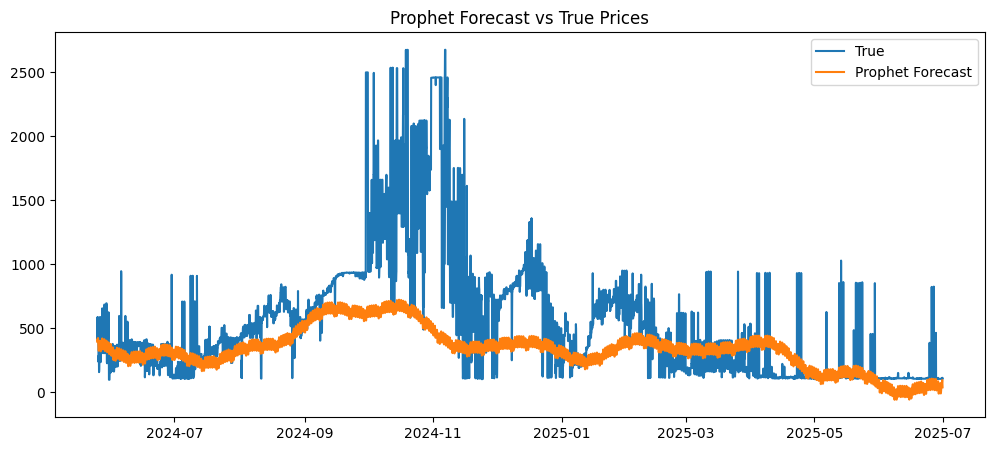

In [59]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 249.43, RMSE: 438.36, R2: 0.24


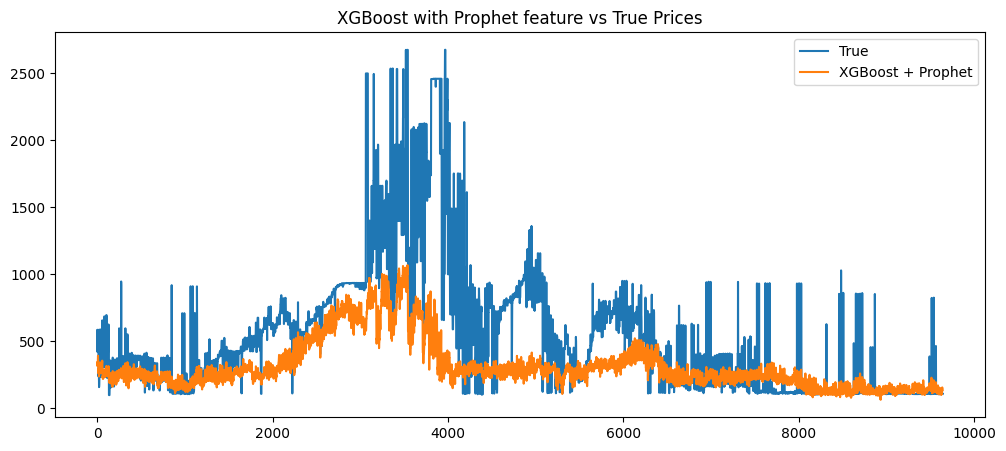

In [60]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
mse_p = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [61]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [62]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,2020,1,2,0,1608662.67,4585681.98,0.0,19184.34,4908.48,1.0,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,2020,1,2,1,1508655.14,4466153.60,0.0,19342.06,3836.61,1.0,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,2020,1,2,2,1413968.65,4520386.10,0.0,20345.52,5343.35,1.0,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,2020,1,2,3,1369278.08,4470436.67,0.0,21123.41,3942.81,1.0,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,2020,1,2,4,1353049.36,4558570.93,0.0,25773.80,2363.15,1.0,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 91.76, RMSE: 256.08, R2: 0.74


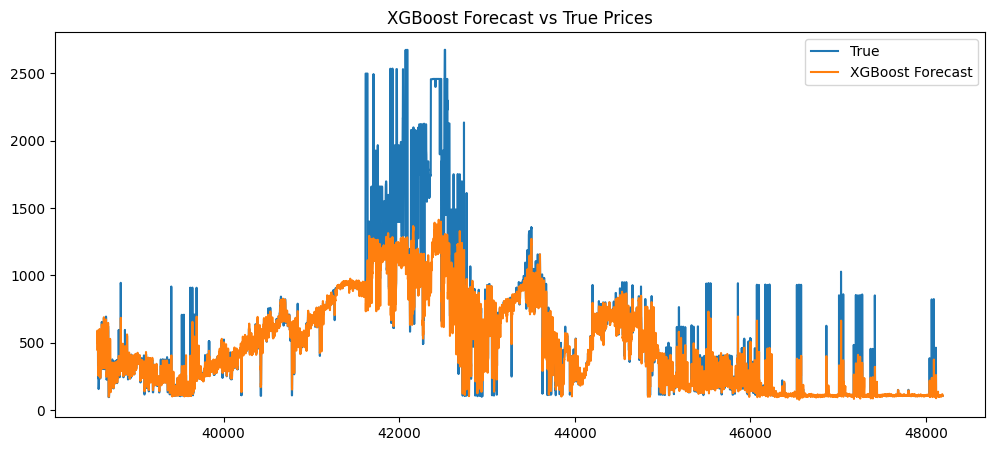

In [63]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [64]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [65]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10025
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 50
[LightGBM] [Info] Start training from score 318.370624
                MAE        RMSE        R2
XGBoost   92.646203  259.006898  0.733174
LightGBM  82.123527  227.392266  0.794337
CatBoost  81.140464  224.742481  0.799102


### Boosting with lags (tunning)

In [68]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [69]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-08-24 19:14:27,375] A new study created in memory with name: no-name-65b33649-ee75-4a92-b100-3677438b7114


Running Optuna for XGBoost...


[I 2025-08-24 19:14:39,600] Trial 0 finished with value: 251.25592774625912 and parameters: {'n_estimators': 349, 'learning_rate': 0.012526367643728834, 'max_depth': 10, 'subsample': 0.7342796596361827, 'colsample_bytree': 0.9198582625140072, 'gamma': 3.273105344151733, 'reg_alpha': 2.067655444778797, 'reg_lambda': 4.200630126671903}. Best is trial 0 with value: 251.25592774625912.
[I 2025-08-24 19:15:11,900] Trial 1 finished with value: 255.92597240859675 and parameters: {'n_estimators': 1326, 'learning_rate': 0.015868835881598244, 'max_depth': 9, 'subsample': 0.86527115066014, 'colsample_bytree': 0.9711496632087522, 'gamma': 1.1469168514086192, 'reg_alpha': 4.3608817135005316, 'reg_lambda': 2.1490899037504456}. Best is trial 0 with value: 251.25592774625912.
[I 2025-08-24 19:15:24,328] Trial 2 finished with value: 243.21036156300747 and parameters: {'n_estimators': 737, 'learning_rate': 0.027509735058030053, 'max_depth': 8, 'subsample': 0.6655753337279805, 'colsample_bytree': 0.92513

Best params for XGBoost: {'n_estimators': 666, 'learning_rate': 0.013534898944254924, 'max_depth': 3, 'subsample': 0.6357424171235182, 'colsample_bytree': 0.7791701609405982, 'gamma': 3.3829045180585116, 'reg_alpha': 4.449265081712149, 'reg_lambda': 1.9440726328338458}
Best RMSE: 215.8980

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10025
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 50
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

[I 2025-08-24 19:24:37,382] Trial 0 finished with value: 223.02566730082543 and parameters: {'n_estimators': 1330, 'learning_rate': 0.028463211592418994, 'num_leaves': 95, 'max_depth': 8, 'min_child_samples': 64, 'subsample': 0.8244290165934176, 'colsample_bytree': 0.8883510547914233}. Best is trial 0 with value: 223.02566730082543.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10025
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 50
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

[I 2025-08-24 19:41:22,873] Trial 99 finished with value: 232.94592480831136 and parameters: {'n_estimators': 1197, 'learning_rate': 0.018512443221533764, 'num_leaves': 208, 'max_depth': 12, 'min_child_samples': 13, 'subsample': 0.8892410700718132, 'colsample_bytree': 0.7650954793102519}. Best is trial 93 with value: 211.8693457438484.
[I 2025-08-24 19:41:22,888] A new study created in memory with name: no-name-3c01ae71-58c3-420b-8ea5-39df75251467


Best params for LightGBM: {'n_estimators': 966, 'learning_rate': 0.02172812575914737, 'num_leaves': 284, 'max_depth': 3, 'min_child_samples': 10, 'subsample': 0.8316028658029941, 'colsample_bytree': 0.7687548581144342}
Best RMSE: 211.8693

Running Optuna for CatBoost...


[I 2025-08-24 19:41:32,650] Trial 0 finished with value: 248.25006712298776 and parameters: {'iterations': 1178, 'learning_rate': 0.22721761293183962, 'depth': 3, 'l2_leaf_reg': 4.333171279412319, 'bagging_temperature': 0.8282377892714393}. Best is trial 0 with value: 248.25006712298776.
[I 2025-08-24 19:44:35,796] Trial 1 finished with value: 239.19866132713022 and parameters: {'iterations': 1414, 'learning_rate': 0.014199433782888392, 'depth': 10, 'l2_leaf_reg': 7.0356628259319836, 'bagging_temperature': 0.2976656493708659}. Best is trial 1 with value: 239.19866132713022.
[I 2025-08-24 19:44:42,632] Trial 2 finished with value: 218.94377700464847 and parameters: {'iterations': 823, 'learning_rate': 0.026494427684864968, 'depth': 3, 'l2_leaf_reg': 9.338389884939371, 'bagging_temperature': 0.003952968145423452}. Best is trial 2 with value: 218.94377700464847.
[I 2025-08-24 19:45:00,864] Trial 3 finished with value: 240.67917971153986 and parameters: {'iterations': 461, 'learning_rate':

Best params for CatBoost: {'iterations': 1354, 'learning_rate': 0.01237735071748993, 'depth': 3, 'l2_leaf_reg': 7.103275719777683, 'bagging_temperature': 0.921070760671912}
Best RMSE: 215.4961

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10025
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 50
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [70]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost          666.0       0.013535        3.0   0.635742          0.779170   
LightGBM         966.0       0.021728        3.0   0.831603          0.768755   
CatBoost           NaN       0.012377        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   3.382905   4.449265    1.944073         NaN                NaN   
LightGBM       NaN        NaN         NaN       284.0               10.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  215.898043  
LightGBM         NaN    NaN          NaN                  NaN  211.869346  
CatBoost      1354.0    3.0     7.103276             0.921071  215.496146  
                MAE   

### Baseline models with lag

In [71]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse  rmse
Linear Regression  0.949127   26.661680   4547.671104   NaN
Ridge              0.949126   26.660651   4547.663441   NaN
Lasso              0.949821   26.325657   4546.682486   NaN
ElasticNet         0.949442   26.393240   4548.940523   NaN
Decision Tree      0.669878   72.575524  40546.168939   NaN
Random Forest      0.810834   57.509410  25320.973210   NaN
Gradient Boosting  0.841084   51.637983  26179.115376   NaN
SVR               -0.073263  180.877049  88077.810170   NaN
KNN                0.106742  151.601034  67417.792315   NaN


### Baseline models (linear) with lag (tunning)

In [72]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [73]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.949127,26.66168,55.574775
Ridge,{'alpha': 100},0.94929,26.59335,55.544331
Lasso,{'alpha': 0.1},0.949775,26.364909,55.439048
ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.9}",0.949709,26.368717,55.448288


In [ ]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [74]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [75]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [76]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-08-24 22:38:29,628] A new study created in memory with name: no-name-ddcd2e0c-636e-41b3-8b7a-53bfdce9e7fc
[I 2025-08-24 22:38:35,605] Trial 9 finished with value: 123.62691204575476 and parameters: {'max_depth': 3, 'min_samples_split': 11}. Best is trial 9 with value: 123.62691204575476.
[I 2025-08-24 22:38:35,867] Trial 13 finished with value: 123.62691204575476 and parameters: {'max_depth': 3, 'min_samples_split': 17}. Best is trial 9 with value: 123.62691204575476.
[I 2025-08-24 22:38:39,308] Trial 0 finished with value: 98.27219903349864 and parameters: {'max_depth': 5, 'min_samples_split': 4}. Best is trial 0 with value: 98.27219903349864.
[I 2025-08-24 22:38:41,386] Trial 19 finished with value: 132.89285970518083 and parameters: {'max_depth': 6, 'min_samples_split': 17}. Best is trial 0 with value: 98.27219903349864.
[I 2025-08-24 22:38:43,709] Trial 21 finished with value: 101.28283532873778 and parameters: {'max_depth': 4, 'min_samples_split': 13}. Best is trial 0 with

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 4}",0.854741,46.932371,98.272199
Random Forest,"{'n_estimators': 854, 'max_depth': 4, 'min_sam...",0.86286,47.717815,101.84627
Gradient Boosting,"{'n_estimators': 167, 'learning_rate': 0.02329...",0.866324,47.547503,99.747225


In [77]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 4},
  'R2': 0.8547406385393647,
  'MAE': 46.93237062683123,
  'RMSE': 98.27219903349864},
 'Random Forest': {'Best Params': {'n_estimators': 854,
   'max_depth': 4,
   'min_samples_split': 17,
   'max_features': None},
  'R2': 0.8628602360955673,
  'MAE': 47.71781467647317,
  'RMSE': 101.84626980874023},
 'Gradient Boosting': {'Best Params': {'n_estimators': 167,
   'learning_rate': 0.023299228243351486,
   'max_depth': 2,
   'subsample': 0.7089878787594117},
  'R2': 0.8663237727336597,
  'MAE': 47.54750263511919,
  'RMSE': 99.74722532419699}}

In [ ]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [ ]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [ ]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [78]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [79]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                                r2          mae           mse         rmse
Extra Trees               0.902854    37.952475  1.578738e+04    84.623306
Hist Gradient Boosting    0.915211    34.362739  1.188288e+04    77.802471
MLP Regressor          -207.489764  1879.426274  5.234046e+06  2071.837756


<hr>

## Long short-term memory (LSTM)

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'SOLAR', 'COGENERADOR', 'EOLICA', 'FUEL_CONS_ACPM', 'FUEL_CONS_CARBON', 'FUEL_CONS_COMBUSTOLEO', 'FUEL_CONS_CRUDO', 'FUEL_CONS_GAS', 'FUEL_CONS_GAS_NI', 'FUEL_CONS_GLP', 'FUEL_COST_CARBON', 'FUEL_COST_GAS', 'FUEL_COST_GAS_NI', 'FUEL_COST_COMBUSTOLEO', 'IPC_VAR_MOM_PCT', 'IPP_VAR_PN_MOM_PCT', 'IPP_VAR_OI_MOM_PCT']


In [10]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,...,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT,DIA_SEMANA,FESTIVO
0,2020,1,1,0,72.02,0.363247,0.269862,0.000000,0.189648,0.100633,...,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597,3,1
1,2020,1,1,1,136.71,0.310187,0.286300,0.000000,0.191136,0.082356,...,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597,3,1
2,2020,1,1,2,127.71,0.278933,0.283414,0.000000,0.170337,0.061953,...,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597,3,1
3,2020,1,1,3,127.71,0.263346,0.274959,0.000000,0.168444,0.071108,...,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597,3,1
4,2020,1,1,4,127.71,0.276951,0.252457,0.000000,0.165776,0.058972,...,0.0,0.586930,0.006646,0.000000,0.054313,0.370370,0.306317,0.255597,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025,6,30,19,112.55,0.190143,0.849097,0.001340,0.578630,0.547735,...,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791,1,1
48188,2025,6,30,20,112.55,0.191153,0.826843,0.000839,0.613528,0.549004,...,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791,1,1
48189,2025,6,30,21,106.25,0.204237,0.784387,0.000000,0.624925,0.546028,...,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791,1,1
48190,2025,6,30,22,105.55,0.209577,0.727481,0.000000,0.651119,0.546691,...,0.0,0.717225,0.051398,0.273668,0.529376,0.222222,0.359952,0.141791,1,1


In [12]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 72  # last 24 hours
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48120, 72, 27)
y shape: (48120,)


In [13]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [14]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 72, 128)           79872     
                                                                 
 dropout (Dropout)           (None, 72, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 131393 (513.25 KB)
Trainable params: 131

In [15]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


482/482 [==============================] - 126s 247ms/step - loss: 39857.4688 - mae: 144.4556 - val_loss: 256210.1406 - val_mae: 426.8130
Epoch 2/50
482/482 [==============================] - 117s 243ms/step - loss: 24271.5059 - mae: 118.7493 - val_loss: 256887.1250 - val_mae: 427.4893
Epoch 3/50
482/482 [==============================] - 118s 244ms/step - loss: 24239.4531 - mae: 118.5507 - val_loss: 252290.9375 - val_mae: 422.8802
Epoch 4/50
482/482 [==============================] - 117s 243ms/step - loss: 19976.9336 - mae: 100.2954 - val_loss: 151782.0781 - val_mae: 308.4838
Epoch 5/50
482/482 [==============================] - 119s 247ms/step - loss: 10260.8076 - mae: 71.6957 - val_loss: 107266.1016 - val_mae: 242.2842
Epoch 6/50
482/482 [==============================] - 120s 248ms/step - loss: 8381.0342 - mae: 68.2683 - val_loss: 99200.8516 - val_mae: 229.7116
Epoch 7/50
482/482 [==============================] - 117s 242ms/step - loss: 5004.8545 - mae: 47.7307 - val

In [16]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 18s 53ms/step
R2: 0.4858905603002157, RMSE: 359.7073, MAE: 146.7377


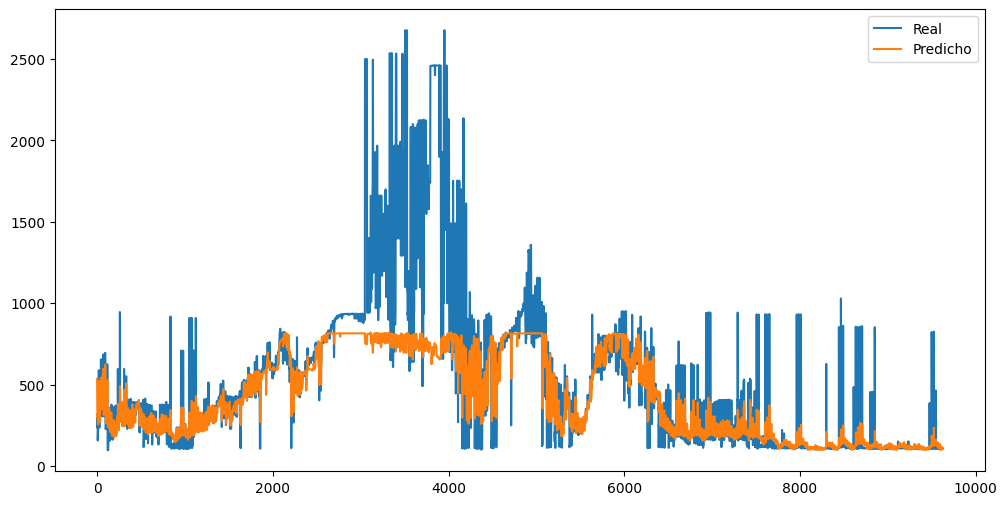

In [17]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()